# ORB (Oriented FAST and Rotated BRIEF)

In [1]:
import cv2
import numpy as np
import time
from google.colab import drive
from google.colab.patches import cv2_imshow
drive.mount('/content/drive/')

Mounted at /content/drive/


In [10]:
# /content/drive/MyDrive/Colab Notebooks/images
IMG1_PATH = "/content/drive/MyDrive/Colab Notebooks/images/picture1.jpg"   # objecy
IMG2_PATH = "/content/drive/MyDrive/Colab Notebooks/images/picture2.jpg"   # scene


img1_color = cv2.imread(IMG1_PATH)
img2_color = cv2.imread(IMG2_PATH)
if img1_color is None or img2_color is None:
   raise FileNotFoundError("Patikrinkite IMG1_PATH ir IMG2_PATH!")

img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

# Create the ORB detector (controls how features are found)

In [11]:
# Initialize the ORB detector
orb = cv2.ORB_create(
 nfeatures=500,
 scaleFactor=1.2,
 nlevels=8,
 edgeThreshold=31
)


# Detect keypoints + compute descriptors

Match descriptors with BFMatcher (Hamming distance)

In [12]:

# Detect ORB keypoints and compute descriptors
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print(f"Image 1: {len(kp1)} keypoints, descriptors: {des1.shape} (uint8)")
print(f"Image 2: {len(kp2)} keypoints, descriptors: {des2.shape}")

# Initialize the Brute Force Matcher using Hamming distance
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

# Find the 2 nearest neighbors for each descriptor
matches_knn = bf.knnMatch(des1, des2, k=2)

good_matches = []
ratio_thresh = 0.75

# Apply the ratio test
for m, n in matches_knn:
 if m.distance < ratio_thresh * n.distance:
  good_matches.append(m)

print(f"Good matches: {len(good_matches)}")

Image 1: 500 keypoints, descriptors: (500, 32) (uint8)
Image 2: 500 keypoints, descriptors: (500, 32)
Good matches: 10


# Visualization ORB

In [13]:
# Select the number of matches to display
N_DRAW = min(50, len(good_matches))

# Draw the matches between the two color images
matched_img = cv2.drawMatches(
 img1_color, kp1, img2_color, kp2,
 good_matches[:N_DRAW], None,
 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Draw rich keypoints (showing size and orientation) for both images
img1_kp = cv2.drawKeypoints(img1_color, kp1, None,
 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

img2_kp = cv2.drawKeypoints(img2_color, kp2, None,
 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the resulting images
print("ORB Keypoints for Image 1:")
cv2_imshow(img1_kp)

print("ORB Keypoints for Image 2:")
cv2_imshow(img2_kp)

print("ORB Feature Matches:")
cv2_imshow(matched_img)


Output hidden; open in https://colab.research.google.com to view.

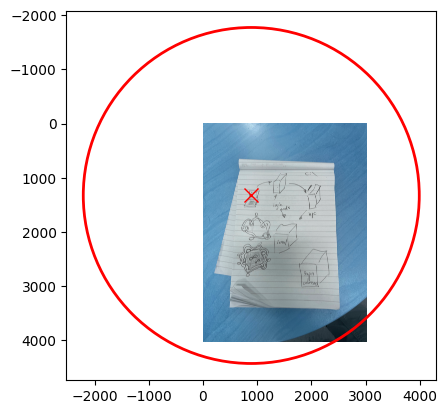

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a plot to visualize a single keypoint
fig, ax = plt.subplots()
ax.imshow(img1_color)

# Define the keypoint to visualize (index 100)
target_kp = kp1[100]

# Create a circle object centered at the keypoint coordinates (.pt)
# The radius is multiplied by 100 to make it clearly visible on the plot
circle = patches.Circle(
 target_kp.pt,
 radius=target_kp.size * 100,
 edgecolor='red',
 facecolor='none',
 linewidth=2
)

# Add the circle to the plot axes
ax.add_patch(circle)

# Mark the center of the keypoint with an 'x'
ax.plot(target_kp.pt[0], target_kp.pt[1], marker='x', color='red', markersize=10)

plt.show()